# Comparacion de los modelos

In [2]:
# Importacion de librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Librerias para el preprocesado, métricas y modelos
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

In [3]:
# Se cargan los daatos de prueba (procesados)
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

X_train = train_df.drop(columns=['target']).values
y_train = train_df['target'].values

X_test = test_df.drop(columns=['target']).values
y_test = test_df['target'].values

# Escalado
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Versión one-hot de y_test para el Modelo2
y_test_cat = to_categorical(y_test, num_classes=4)

In [4]:
# Cargas los modelos realizados
# Modelo#1:
model_1 = keras.models.load_model('modelo_pred_ar.keras')
# Modelo#2:
model_2 = keras.models.load_model('modelo_pred_pm.keras')

C:\proyectogit\ProyectoA_RiesgoCrediticio\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.5698 
Loss: 0.5698
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Accuracy: 0.7500

Classification Report (Modelo 1):
              precision    recall  f1-score   support

           0       0.89      0.74      0.80       140
           1       0.56      0.78      0.65        60

    accuracy                           0.75       200
   macro avg       0.72      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200



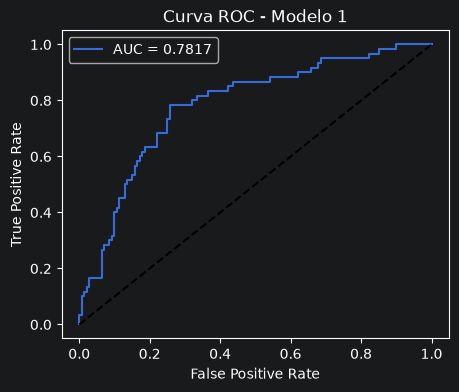

AUC: 0.7817


In [5]:
# Evaluacion del modelo#1
# Pérdida
# Este codigo lo que hace es hacer un recorrido por X_test y hace predicciones internamente y las compara con y_test
loss_1 = model_1.evaluate(X_test, y_test)
print(f"Loss: {loss_1:.4f}")

# Predicciones
# Devuelve para cada fila de X_test una probabilidad entre 0 y 1, y el flatten lo convierte en array plano para facilitar operaciones
y_pred_prob_1 = model_1.predict(X_test).flatten()
# Convierte cada probabilidad en una prediccion de clase
y_pred_1 = (y_pred_prob_1 > 0.5).astype(int)

# Accuracy
# Compara elemento por elemento, la prediccion contra el valor real
acc_1 = (y_pred_1 == y_test).mean()
print(f"Accuracy: {acc_1:.4f}")

# Classification report
print("\nClassification Report (Modelo 1):")
print(classification_report(y_test, y_pred_1))

# Curva ROC y AUC
# Esto sirve para evaluar el rendimiento de un modelo de clasificacion binaria 
fpr_1, tpr_1, _ = roc_curve(y_test, y_pred_prob_1)
auc_1 = roc_auc_score(y_test, y_pred_prob_1)

plt.figure(figsize=(5,4))
plt.plot(fpr_1, tpr_1, label=f'AUC = {auc_1:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Modelo 1')
plt.legend()
plt.show()
print(f"AUC: {auc_1:.4f}")

In [7]:
# Evaluacion del modelo#2

# Pérdida y categorical_accuracy
# Mide que tan penalizadas o alejadas estuvieron las probabilidades y el porcentaje de acierto del modelo
loss_2, acc_2 = model_2.evaluate(X_test, y_test_cat)
print(f"Loss: {loss_2:.4f}")
print(f"Accuracy: {acc_2:.4f}")

# Predicciones
# Se estima las probabilidades para cada fila y busca para cual de las 4 neuronas tuvo el valor de probabilidad mas alto
y_pred_prob_2 = model_2.predict(X_test)
y_pred_2 = np.argmax(y_pred_prob_2, axis=1)

# Classification report (sobre las etiquetas reales 0/1)
print("\nClassification Report (Modelo 2):")
print(classification_report(y_test, y_pred_2, labels=[0,1,2,3], zero_division=0))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - categorical_accuracy: 0.7000 - loss: 0.6977 
Loss: 0.6977
Accuracy: 0.7000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Classification Report (Modelo 2):
              precision    recall  f1-score   support

           0       0.70      0.99      0.82       140
           1       0.50      0.02      0.03        60
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0

    accuracy                           0.70       200
   macro avg       0.30      0.25      0.21       200
weighted avg       0.64      0.70      0.59       200



               Modelo  Accuracy     Loss       AUC
   Modelo 1 (Binaria)      0.75 0.569843  0.781667
Modelo 2 (Multiclase)      0.70 0.697663         -


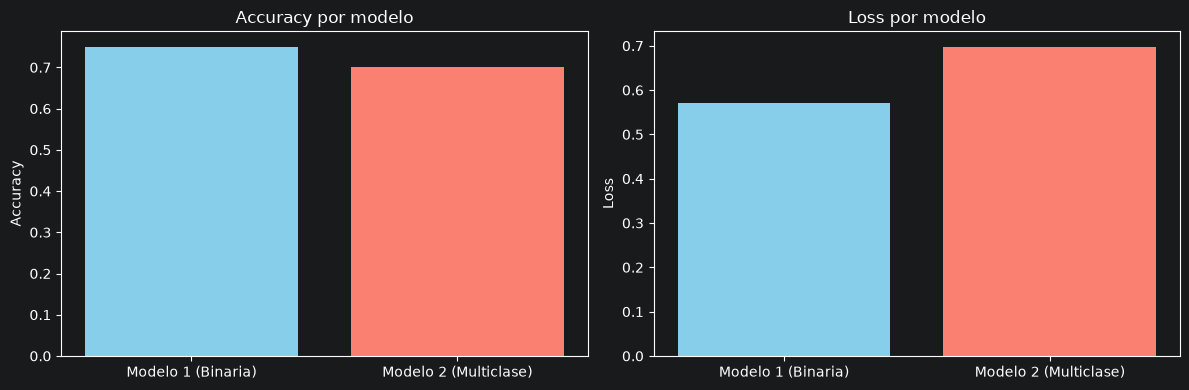

In [8]:
# Comparacion de metricas

# Crear DataFrame comparativo
comparison = pd.DataFrame({
    'Modelo': ['Modelo 1 (Binaria)', 'Modelo 2 (Multiclase)'],
    'Accuracy': [acc_1, acc_2],
    'Loss': [loss_1, loss_2]
})

# Para el modelo binario, añadir AUC
comparison['AUC'] = [auc_1, '-']

print(comparison.to_string(index=False))

# Visualización gráfica
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].bar(comparison['Modelo'], comparison['Accuracy'], color=['skyblue', 'salmon'])
axes[0].set_title('Accuracy por modelo')
axes[0].set_ylabel('Accuracy')

axes[1].bar(comparison['Modelo'], comparison['Loss'], color=['skyblue', 'salmon'])
axes[1].set_title('Loss por modelo')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()